In [1]:
import pandas as pd

# Loading the data
url_emails_cleaned = 'https://raw.githubusercontent.com/Drakey-504/synthetic-phishing-generation-and-detection/main/data/processed/emails_clean.csv'
url_synthetic_phishing = 'https://raw.githubusercontent.com/Drakey-504/synthetic-phishing-generation-and-detection/main/data/processed/synthetic_phishing.csv'

emails_clean = pd.read_csv(url_emails_cleaned)
synthetic_phishing = pd.read_csv(url_synthetic_phishing)

print(emails_clean.columns.tolist())
print(synthetic_phishing.columns.tolist())

# labeled phishing or legitimate
# emails_clean
# synthetic_phishing.head()



['id', 'source', 'subject', 'text', 'label', 'split']
['id', 'method', 'sophistication', 'scenario', 'prompt_id', 'model', 'temperature', 'subject', 'text', 'label']


In [2]:

TEXT_COL = 'text'

label_map = {'legitimate': 0, 'phishing': 1}
synthetic_phishing['label'] = synthetic_phishing['label'].map(label_map)
emails_clean['label'] = emails_clean['label'].map(label_map)


emails_clean['source']        = 'real'
synthetic_phishing['source']  = 'synthetic'

combined = pd.concat([synthetic_phishing, emails_clean], ignore_index=True)
combined = combined[[TEXT_COL, 'label', 'source']].dropna()


# combined = pd.concat([synthetic_phishing, emails_clean], ignore_index=True)
# combined = combined[[TEXT_COL, 'label']].dropna()

print(combined[['label', 'source']].value_counts())
combined


label  source   
0      real         8398
1      real         4835
       synthetic     460
Name: count, dtype: int64


,text,label,source
0,"Dear Emily Chen,\n\nWe have temporarily suspen...",1,synthetic
1,"Dear Julia Rodriguez,\n\nWe've temporarily sus...",1,synthetic
2,"Dear Emily Wilson,\n\nWe're writing to inform ...",1,synthetic
3,"Dear Rachel Thompson,\n\nWe have temporarily s...",1,synthetic
4,"Dear Rachel Davis,\n\nWe've detected some unus...",1,synthetic
...,...,...,...
13688,http://news.bbc.co.uk/1/hi/england/2515127.stm...,0,real
13689,"> >-- be careful when using this one.) Also, t...",0,real
13690,">>>>> ""SM"" == Skip Montanaro writes:\n\nJeremy...",0,real
13691,"So then, ""Mark Hammond"" is all like:\n\n> So, ...",0,real


In [3]:
# Preprocessing

import re
from sklearn.model_selection import train_test_split

# reducing noise for logistic classifier
def clean_text(text):
  text = str(text).lower()

  # normalising URLs
  text = re.sub(r'http\S+|www\S+', 'URL', text)

  # normalising emails
  text = re.sub(r'\S+@\S+', 'EMAIL', text)

  #removing whitespace
  text = re.sub(r'\s+', ' ', text).strip()

  return text

combined['clean_text'] = combined[TEXT_COL].apply(clean_text)

# train test split
X = combined['clean_text']
y = combined['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 10954
Test size: 2739


In [4]:
# tf-idf vectorisation
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,    # vocab limit
    ngram_range = (1,2),  #unigrams & bigrams
    sublinear_tf=True,    # log scale tf
    min_df=2,
    )

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# XGBoost Model

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:40:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-logloss:0.60074
[50]	validation_0-logloss:0.07403
[100]	validation_0-logloss:0.04474
[150]	validation_0-logloss:0.03604
[200]	validation_0-logloss:0.03185
[250]	validation_0-logloss:0.02993
[299]	validation_0-logloss:0.02904
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99      1654
    Phishing       0.99      0.98      0.99      1085

    accuracy                           0.99      2739
   macro avg       0.99      0.99      0.99      2739
weighted avg       0.99      0.99      0.99      2739

ROC-AUC: 0.9993

TP: 1066  FP: 6  TN: 1648  FN: 19


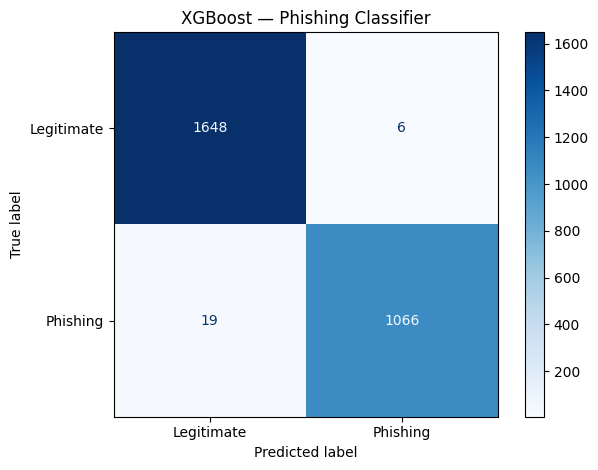

In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

xgb = XGBClassifier(
    n_estimators=300,  # number of trees
    max_depth=6,  # tree depth
    learning_rate=0.1,
    subsample=0.8,  # row subsampling per tree
    colsample_bytree=0.8,  # feature subsampling per tree
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

xgb.fit(
    X_train_vec, y_train,
    eval_set=[(X_test_vec, y_test)],
    verbose=50    #  loss every 50 rounds
)

# evaluation of model
y_pred  = xgb.predict(X_test_vec)
y_proba = xgb.predict_proba(X_test_vec)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# TP, FP, TN, FN
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"\nTP: {tp}  FP: {fp}  TN: {tn}  FN: {fn}")

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Legitimate', 'Phishing']
).plot(cmap='Blues')
plt.title('XGBoost — Phishing Classifier')
plt.tight_layout()
plt.show()

## Evasion Rate for Synthetic Phishing

In [6]:
# evasion rate
combined_test = combined.loc[X_test.index].copy()
combined_test['predicted'] = y_pred

synthetic_test = combined_test[combined_test['source'] == 'synthetic']

if not synthetic_test.empty:
    evasion_rate = (synthetic_test['predicted'] == 0).mean()
    print(f"Synthetic phishing evasion rate: {evasion_rate:.2%}")

Synthetic phishing evasion rate: 0.00%


## Feature Importance

In [7]:
# top features with XGBoost feature importance
import numpy as np

feature_names = tfidf.get_feature_names_out()
importances   = xgb.feature_importances_
top_idx       = np.argsort(importances)[-20:][::-1]

print("Top 20 features by importance:")
for i in top_idx:
    print(f"  {feature_names[i]:<30} {importances[i]:.4f}")

Top 20 features by importance:
  best regards                   0.0566
  your                           0.0515
  account                        0.0418
  monkey org                     0.0359
  million                        0.0276
  this money                     0.0262
  deposit                        0.0253
  dear                           0.0215
  dollars                        0.0200
  shared                         0.0174
  subject                        0.0163
  monkey                         0.0158
  deposited                      0.0133
  org                            0.0118
  your country                   0.0107
  transaction                    0.0106
  subject to                     0.0101
  this email                     0.0100
  2002                           0.0096
  money                          0.0092
